# Imports

We begin by importing the Python libraries needed for data exploration:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FixedLocator


sns.set(style="whitegrid")  


# Load Dataset

The cleaned dataset is loaded into Python. During Excel cleaning:

- Missing values were handled  
- Transactions with `TotalPrice = 0` (returns) were removed  
- Dates were formatted correctly

This ensures the dataset reflects actual sales and is ready for analysis.

In [2]:
# 1️⃣ Load dataset
file_path = "C:/Users/Azang/Documents/retail-sales-analysis/Online-Retaill-II-EDA/data/online_retail_II_clean.xlsx"
df = pd.read_excel(file_path)


# Dataset Overview

We examine the first few rows, column types, and dataset size. Key fields:

- `invoice_date`  
- `customer_id`  
- `country`  
- `description` (product)  
- `quantity`  
- `unit_price`  
- `total_price` (represents revenue)

In [3]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524875 entries, 0 to 524874
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       524875 non-null  object        
 1   stock_code    524875 non-null  object        
 2   description   524875 non-null  object        
 3   price         524875 non-null  float64       
 4   quantity      524875 non-null  int64         
 5   total_price   524875 non-null  float64       
 6   invoice_date  524875 non-null  datetime64[ns]
 7   customer_id   524875 non-null  object        
 8   country       524875 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 36.0+ MB


(524875, 9)

In [4]:
# Data Quality Checks

In [5]:
# Check missing values
df.isnull().sum()

# Check for duplicates
df.duplicated().sum()

# Preview some duplicate rows (if any)
df[df.duplicated()].head()


,invoice,stock_code,description,price,quantity,total_price,invoice_date,customer_id,country


# Basic Explorations 

Initial exploration provides insight into the dataset:

- Summary statistics for numeric columns (`df.describe()`)  
- Count of unique values per column (`df.nunique()`)  
- Helps detect anomalies, outliers, and general data patterns

In [6]:
df.describe()
df.nunique()


invoice         19960
stock_code       3921
description      4025
price            1290
quantity          375
total_price      4905
invoice_date    18499
customer_id      4339
country            38
dtype: int64

In [7]:

df.columns


Index(['invoice', 'stock_code', 'description', 'price', 'quantity',
       'total_price', 'invoice_date', 'customer_id', 'country'],
      dtype='object')

In [13]:
# Verify total_price matches quantity * unit_price
df['total_price_check'] = df['quantity'] * df['price']

# Check mismatches
mismatches = df[df['total_price'] != df['total_price_check']]
print(f"Number of mismatched rows: {mismatches.shape[0]}")

# Show sample mismatches if any
if mismatches.shape[0] > 0:
    display(mismatches[['quantity', 'price','total_price','total_price_check']].head(10))
else:
    print("All total_price values are correct.")

# Optionally fix total_price
df['total_price'] = df['total_price_check']
df.drop(columns='total_price_check', inplace=True)



Number of mismatched rows: 0
All total_price values are correct.


# Revenue by Country

Total revenue is grouped by country to identify key markets. The UK dominates sales, but smaller contributions from other countries suggest opportunities for expansion.

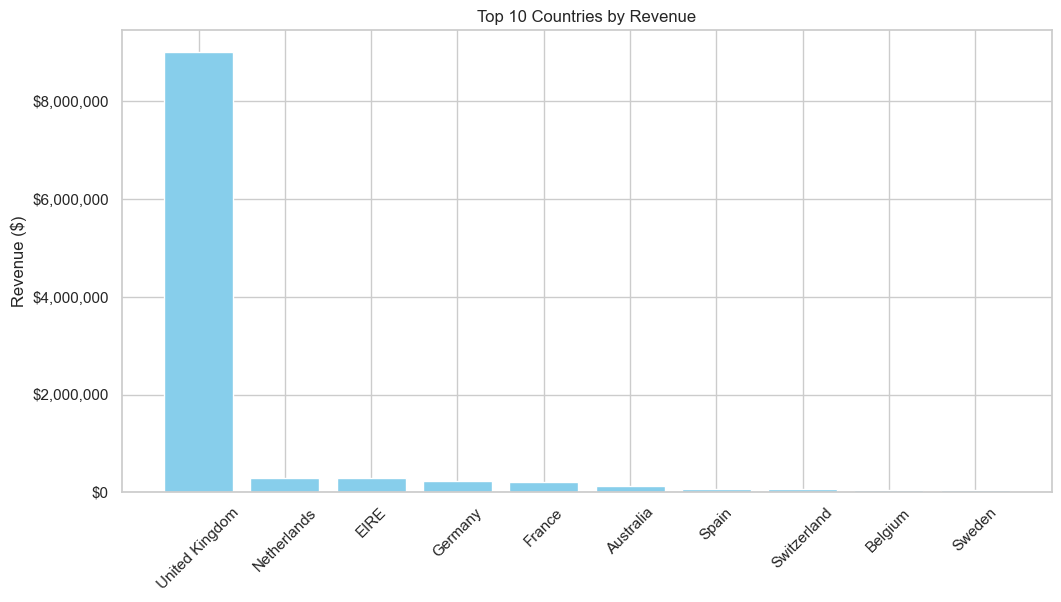

In [15]:
# Revenue per country
# Revenue per country
country_revenue = (
    df.groupby('country')['total_price']
    .sum()
    .sort_values(ascending=False)[:10]   # top 10 countries
)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(country_revenue.index, country_revenue.values, color='skyblue')
ax.set_title("Top 10 Countries by Revenue")
ax.set_ylabel("Revenue ($)")
plt.xticks(rotation=45)

# Turn off offset (prevents showing "millions")
ax.get_yaxis().get_offset_text().set_visible(False)

# Format y-axis with commas, no scientific notation
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.show()



## Top 10 Products by Revenue  

This section identifies the top 10 products by total revenue. These products contribute the most to overall sales and highlight what drives the business.


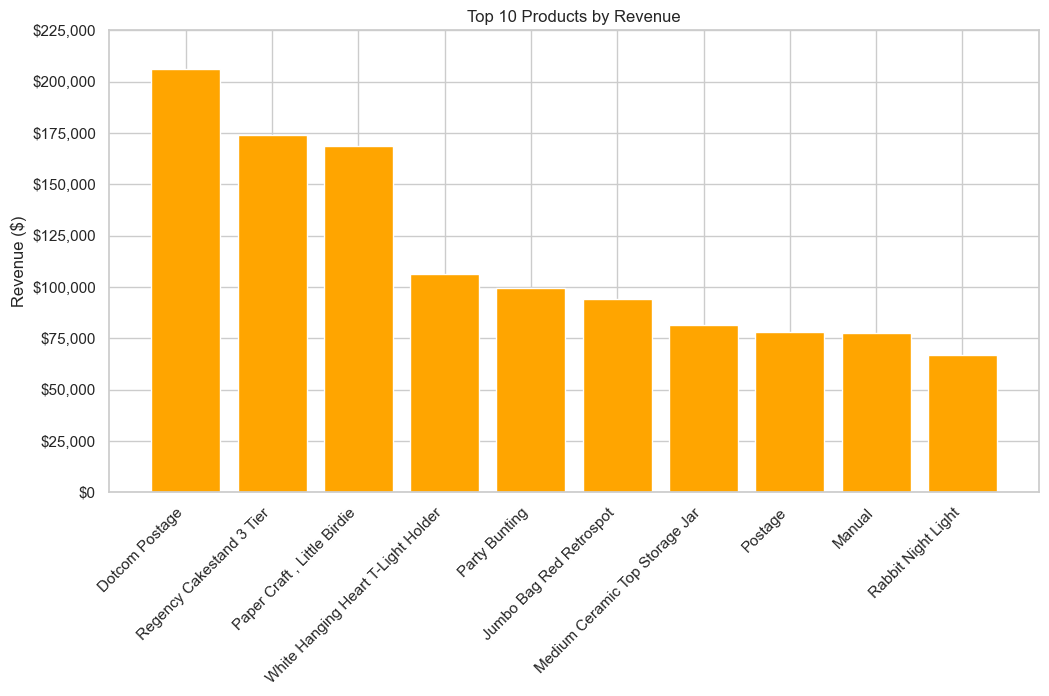

In [16]:
# Top 10 products by revenue
top_products = (
    df.groupby('description')['total_price']
    .sum()
    .sort_values(ascending=False)[:10]
)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(top_products.index, top_products.values, color='orange')
ax.set_title("Top 10 Products by Revenue")
ax.set_ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right")

# Turn off offset (no "x 1e6" etc.)
ax.get_yaxis().get_offset_text().set_visible(False)

# Format y-axis with commas
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Set y-axis ticks (steps of 25,000 since highest product is ~206,249)
max_val = top_products.values.max()
ax.set_yticks(range(0, int(max_val) + 25000, 25000))

plt.show()


# Monthly Revenue Trend

Monthly revenue is calculated and visualized. Since `invoice_date` was already formatted in Excel, we can directly observe trends and seasonality.

This shows months with higher sales, guiding promotions and inventory planning.

C:\Users\Azang\AppData\Local\Temp\ipykernel_33556\3145220589.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.set_index('invoice_date').resample('M')['total_price'].sum()


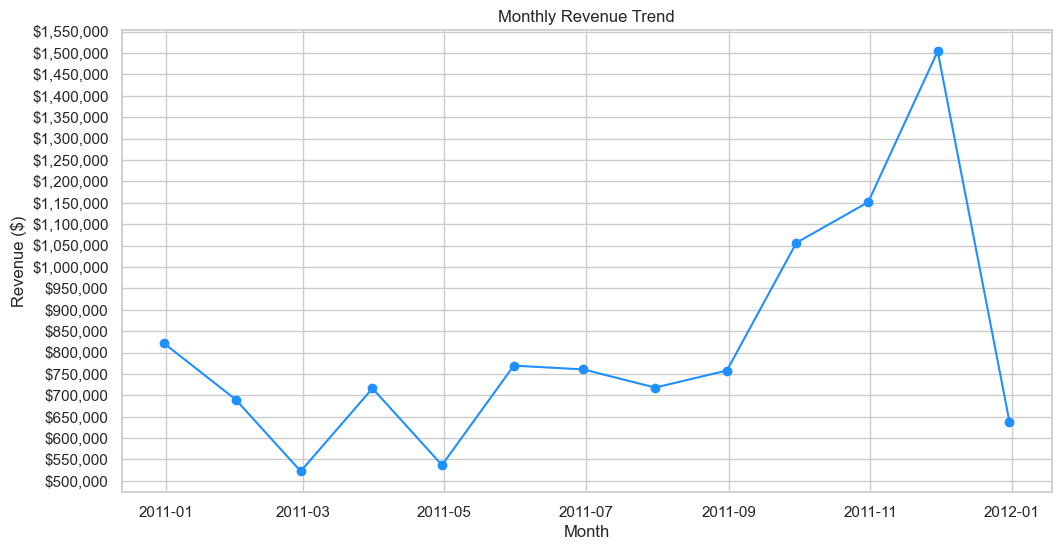

In [18]:
# Ensure InvoiceDate is datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

# Group by month
monthly_revenue = df.set_index('invoice_date').resample('M')['total_price'].sum()

# Plot
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='dodgerblue')
ax.set_title("Monthly Revenue Trend")
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("Month")

# Turn off automatic offset (prevents showing "×10⁶")
ax.get_yaxis().get_offset_text().set_visible(False)

# Force y-axis to show full values with commas
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Optionally, control tick intervals (e.g., every 50000)
from matplotlib.ticker import MultipleLocator
ax.yaxis.set_major_locator(MultipleLocator(50000))

plt.show()


## Key Customers

We ranked customers by total spend to identify the most valuable clients. This helps inform retention and loyalty strategies.


C:\Users\Azang\AppData\Local\Temp\ipykernel_33556\1707114404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette="magma")


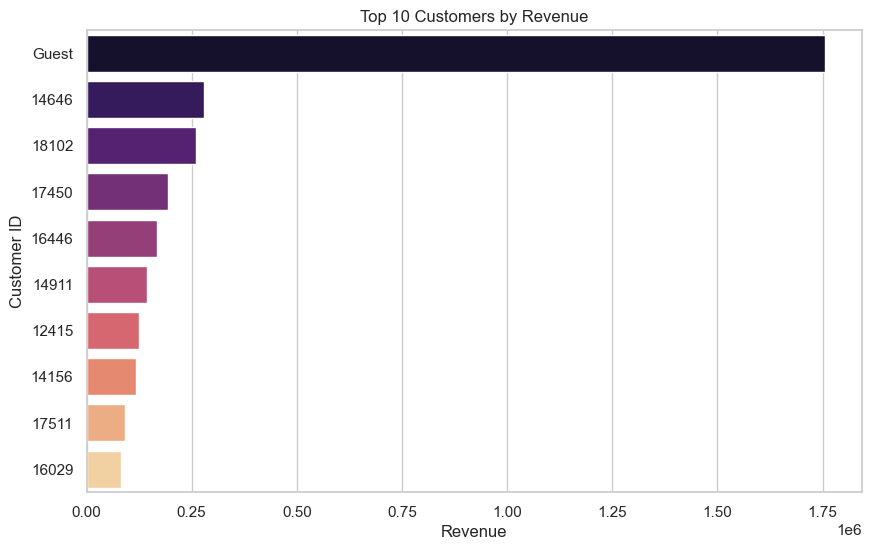

In [19]:
top_customers = df.groupby('customer_id')['total_price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette="magma")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.show()


# Summary of Insights

- Sales fluctuate seasonally, which helps guide planning and campaigns  
- The UK is the primary market, with potential for international growth  
- A small number of products generate the majority of revenue  
- Certain customers provide the most value  
- Initial exploration confirms the dataset is clean and ready for analysis
